# Notebook 14 — Sector Alpha with NLP Sentiment

> *Adding sector-specific news sentiment to the cross-sectional sector rotation model*

## Hypothesis
Sector-specific news sentiment (BANK, ENERGY, ICT, COMMERCE, HEALTH, PROPERTY, FOOD) carries incremental information about **relative** sector performance beyond macro features.

## Approach
| Step | Detail |
|------|--------|
| Data | 1,295 sector-tagged articles (Google News RSS + VADER), 2007–2026 |
| Coverage | 8–16% historical, **40–95% in 2023–2026** |
| Leakage | All NLP features strictly lagged by 1 week |
| Handling | XGBoost native NaN → uses NLP when available, ignores when not |
| Comparison | Walk-forward IC/Sharpe: macro-only (NB13) vs macro+NLP |
| Key test | IC uplift in **NLP coverage era** (2020–2025) |


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from sklearn.base import clone
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11,
})

TC            = 0.001   # 10 bps per side
MIN_TRAIN_W   = 156     # 3 years minimum training
FOLD_SIZE_W   = 52      # 1 year per fold
LONG_K        = 2
SHORT_K       = 2
SECTORS       = ['BANK','ENERGY','ICT','COMMERCE','HEALTH','PROPERTY','FOOD']
NLP_ERA_START = pd.Timestamp('2020-01-01')

print('Setup complete.')


Setup complete.


## Section 1 — Load Data

In [2]:
# ── Sector returns ────────────────────────────────────────────────────────
sector_df = pd.read_csv(PROC / 'sector_weekly.csv', index_col=0, parse_dates=True)
sector_df = sector_df.resample('W-FRI').last()
print(f'Sector data:  {sector_df.shape[0]} weeks x {sector_df.shape[1]} sectors')

# ── Macro features ────────────────────────────────────────────────────────
macro_df = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)
macro_df = macro_df.resample('W-FRI').last()

MACRO_FEATS = [
    'sp500_ret_w','sp500_rvol_4w','sp500_ret_d_lag1',
    'eem_ret_d_lag1','oil_ret_w','oil_ret_d_lag1',
    'gold_ret_w','gold_rvol_4w','dxy_ret_w','dxy_ret_d_lag1',
    'us_10yr_treasury_ret_w','us_2yr_treasury_ret_w',
    'vix_z','regime','yield_curve_slope',
    'SET_index_ret_w','SET_index_rvol_4w',
]
MACRO_FEATS = [f for f in MACRO_FEATS if f in macro_df.columns]
print(f'Macro feats:  {len(MACRO_FEATS)}')

# ── Sector NLP sentiment ──────────────────────────────────────────────────
nlp_df = pd.read_csv(PROC / 'sector_sentiment_weekly.csv', index_col=0, parse_dates=True)
nlp_df = nlp_df.resample('W-FRI').last()
print(f'NLP data:     {nlp_df.shape[0]} weeks x {nlp_df.shape[1]} cols')

# Align all to common date range
common = sector_df.index.intersection(macro_df.index).intersection(nlp_df.index)
sector_df = sector_df.loc[common]
macro_df  = macro_df.loc[common]
nlp_df    = nlp_df.loc[common]
print(f'Common dates: {len(common)} weeks ({common[0].date()} -> {common[-1].date()})')


Sector data:  1356 weeks x 7 sectors
Macro feats:  17
NLP data:     1000 weeks x 21 cols
Common dates: 979 weeks (2007-03-30 -> 2025-12-26)


## Section 2 — NLP Coverage Analysis

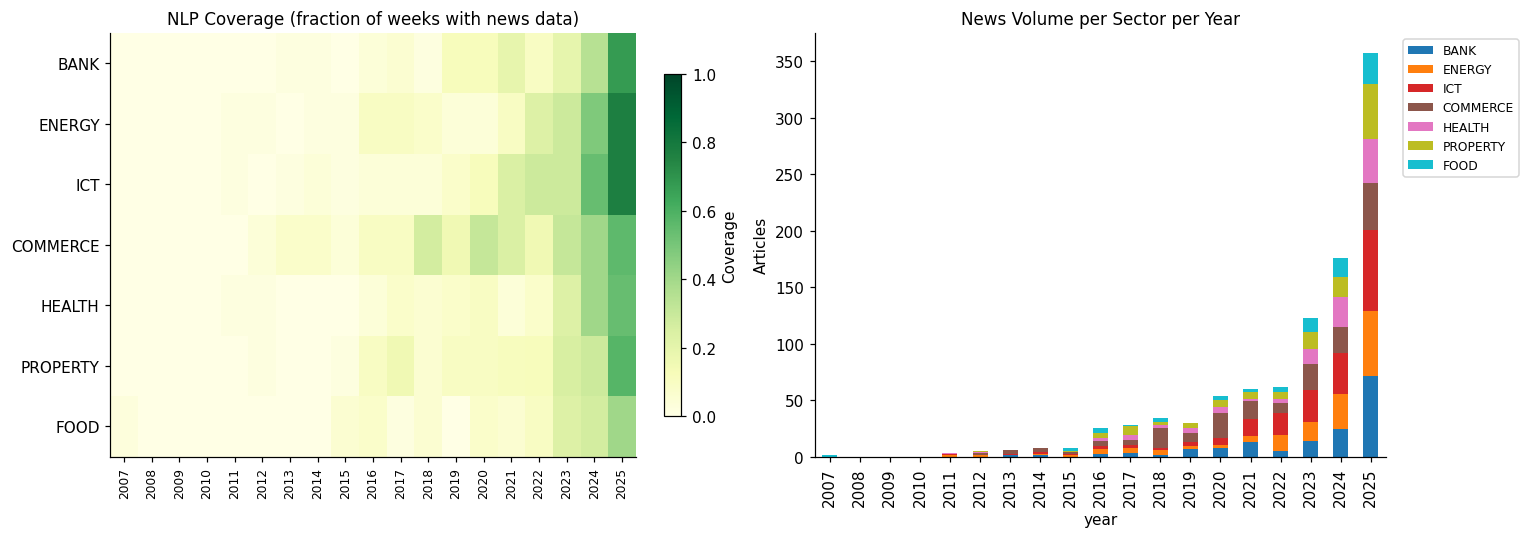

NLP coverage summary:
  NLP era (>=2020): 313 weeks
  BANK        :  98 total,  84 in NLP era
  ENERGY      : 119 total,  99 in NLP era
  ICT         : 132 total, 117 in NLP era
  COMMERCE    : 147 total, 103 in NLP era
  HEALTH      :  87 total,  72 in NLP era
  PROPERTY    :  98 total,  75 in NLP era
  FOOD        :  71 total,  59 in NLP era


In [3]:
sent_cols = [f'{s}_sent' for s in SECTORS]
vol_cols  = [f'{s}_vol'  for s in SECTORS]

# Weekly coverage heatmap by sector and year
cov = nlp_df[sent_cols].copy()
cov.columns = SECTORS
cov['year'] = cov.index.year
yearly_cov = cov.groupby('year')[SECTORS].apply(lambda x: x.notna().mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coverage heatmap
ax = axes[0]
im = ax.imshow(yearly_cov.values.T, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(yearly_cov.index)))
ax.set_xticklabels(yearly_cov.index, rotation=90, fontsize=8)
ax.set_yticks(range(len(SECTORS)))
ax.set_yticklabels(SECTORS)
ax.set_title('NLP Coverage (fraction of weeks with news data)')
plt.colorbar(im, ax=ax, fraction=0.03, label='Coverage')

# Right: total articles per sector over time
ax2 = axes[1]
cov2 = nlp_df[vol_cols].copy()
cov2.columns = SECTORS
cov2['year'] = cov2.index.year
yearly_vol = cov2.groupby('year')[SECTORS].sum()
yearly_vol.plot(kind='bar', stacked=True, ax=ax2, colormap='tab10', legend=True)
ax2.set_title('News Volume per Sector per Year')
ax2.set_ylabel('Articles')
ax2.tick_params(axis='x', rotation=90)
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / 'nlp_coverage.png', dpi=110, bbox_inches='tight')
plt.show()

print('NLP coverage summary:')
print(f'  NLP era (>=2020): {(nlp_df.index >= NLP_ERA_START).sum()} weeks')
for s in SECTORS:
    col = f'{s}_sent'
    total = nlp_df[col].notna().sum()
    era   = nlp_df.loc[nlp_df.index >= NLP_ERA_START, col].notna().sum()
    print(f'  {s:12s}: {total:3d} total, {era:3d} in NLP era')


## Section 3 — Feature Engineering: Sector NLP Features

In [4]:
def build_nlp_features(nlp_df, sectors):
    """Build sector-specific NLP features — all strictly lagged 1 week."""
    feats = {}

    sent_raw = nlp_df[[f'{s}_sent' for s in sectors]].copy()
    sent_raw.columns = sectors
    vol_raw  = nlp_df[[f'{s}_vol' for s in sectors]].copy()
    vol_raw.columns  = sectors
    pos_raw  = nlp_df[[f'{s}_pos' for s in sectors]].copy()
    pos_raw.columns  = sectors

    for s in sectors:
        raw = sent_raw[s]
        vol = vol_raw[s]

        # Lag 1 week (no lookahead)
        feats[f'{s}_sent_lag1']    = raw.shift(1)

        # 4-week rolling mean (lagged)
        feats[f'{s}_sent_4w']      = raw.shift(1).rolling(4, min_periods=1).mean()

        # Sentiment surprise: deviation from 4w mean
        sent_ma = raw.shift(1).rolling(4, min_periods=1).mean()
        feats[f'{s}_sent_surp']    = raw.shift(1) - sent_ma.shift(1)

        # News volume lag1 (more news = higher activity)
        feats[f'{s}_news_vol']     = vol.shift(1).fillna(0)

    # Cross-sectional relative sentiment (sector vs mean of all sectors)
    sent_lag = sent_raw.shift(1)
    mkt_sent = sent_lag.mean(axis=1)
    for s in sectors:
        feats[f'{s}_sent_rel']     = sent_lag[s] - mkt_sent

    return pd.DataFrame(feats, index=nlp_df.index)


nlp_feats = build_nlp_features(nlp_df, SECTORS)
print(f'NLP features built: {nlp_feats.shape[1]} columns')
print(f'Features: {list(nlp_feats.columns[:8])} ...')

# Coverage check
lag1_cols = [f'{s}_sent_lag1' for s in SECTORS]
era_mask = nlp_feats.index >= NLP_ERA_START
era_cov = nlp_feats.loc[era_mask, lag1_cols].notna().mean()
print(f'\nNLP-era (2020+) sent_lag1 coverage:')
for c, v in era_cov.items():
    print(f'  {c:20s}: {v:.0%}')


NLP features built: 35 columns
Features: ['BANK_sent_lag1', 'BANK_sent_4w', 'BANK_sent_surp', 'BANK_news_vol', 'ENERGY_sent_lag1', 'ENERGY_sent_4w', 'ENERGY_sent_surp', 'ENERGY_news_vol'] ...

NLP-era (2020+) sent_lag1 coverage:
  BANK_sent_lag1      : 27%
  ENERGY_sent_lag1    : 31%
  ICT_sent_lag1       : 37%
  COMMERCE_sent_lag1  : 33%
  HEALTH_sent_lag1    : 23%
  PROPERTY_sent_lag1  : 24%
  FOOD_sent_lag1      : 19%


## Section 4 — Build Panel (Sector + Macro + NLP)

In [5]:
SECTOR_FEATS = ['mom1','mom4','mom12','mom26','rvol4','rvol12',
                'mom1_rank','mom4_rank','mom12_rank','mom1_rel','mom4_rel']

NLP_FEATS = [c for c in nlp_feats.columns]

def build_panel(sector_df, macro_df, nlp_feats_df):
    mom1  = sector_df.shift(1)
    mom4  = sector_df.shift(1).rolling(4).mean()
    mom12 = sector_df.shift(1).rolling(12).mean()
    mom26 = sector_df.shift(1).rolling(26).mean()
    rvol4 = sector_df.shift(1).rolling(4).std()
    rvol12= sector_df.shift(1).rolling(12).std()
    mom1_rank  = mom1.rank(axis=1, pct=True) - 0.5
    mom4_rank  = mom4.rank(axis=1, pct=True) - 0.5
    mom12_rank = mom12.rank(axis=1, pct=True) - 0.5
    mkt_mom1 = mom1.mean(axis=1)
    mkt_mom4 = mom4.mean(axis=1)
    mom1_rel = mom1.subtract(mkt_mom1, axis=0)
    mom4_rel = mom4.subtract(mkt_mom4, axis=0)
    fwd_ret  = sector_df.shift(-1)

    dates = sector_df.index
    rows  = []
    for date in dates:
        fwd_vals = fwd_ret.loc[date]
        if fwd_vals.isna().all():
            continue
        mkt_fwd = fwd_vals.mean()
        for sec in sector_df.columns:
            if pd.isna(fwd_vals[sec]):
                continue
            row = {
                'date': date, 'sector': sec,
                'fwd_ret': fwd_vals[sec],
                'fwd_excess': fwd_vals[sec] - mkt_fwd,
                'mom1':       mom1.loc[date, sec],
                'mom4':       mom4.loc[date, sec],
                'mom12':      mom12.loc[date, sec],
                'mom26':      mom26.loc[date, sec],
                'rvol4':      rvol4.loc[date, sec],
                'rvol12':     rvol12.loc[date, sec],
                'mom1_rank':  mom1_rank.loc[date, sec],
                'mom4_rank':  mom4_rank.loc[date, sec],
                'mom12_rank': mom12_rank.loc[date, sec],
                'mom1_rel':   mom1_rel.loc[date, sec],
                'mom4_rel':   mom4_rel.loc[date, sec],
            }
            # Macro features (same for all sectors at this date)
            for f in MACRO_FEATS:
                row[f] = macro_df.loc[date, f] if date in macro_df.index else np.nan
            # NLP features (sector-specific)
            for f in NLP_FEATS:
                # Each NLP feature col is named SECTOR_...
                # Match to the sector: e.g. 'BANK_sent_lag1' -> sec='BANK'
                row[f] = nlp_feats_df.loc[date, f] if date in nlp_feats_df.index else np.nan
            rows.append(row)

    panel = pd.DataFrame(rows)
    panel['date'] = pd.to_datetime(panel['date'])
    return panel


print('Building feature panel (sector + macro + NLP)...')
panel_raw = build_panel(sector_df, macro_df, nlp_feats)

# Drop rows where target is NaN, keep rows with sector features even if NLP is NaN
panel = panel_raw.dropna(subset=['fwd_excess'])
n_dates = panel['date'].nunique()
print(f'Panel: {len(panel)} rows, {n_dates} dates')

ALL_FEATS    = SECTOR_FEATS + MACRO_FEATS + NLP_FEATS
ALL_FEATS    = [f for f in ALL_FEATS if f in panel.columns]
MACRO_ONLY   = [f for f in SECTOR_FEATS + MACRO_FEATS if f in panel.columns]
print(f'Total features: {len(ALL_FEATS)} ({len(MACRO_ONLY)} macro-only, {len(NLP_FEATS)} NLP)')


Building feature panel (sector + macro + NLP)...


Panel: 6846 rows, 978 dates
Total features: 63 (28 macro-only, 35 NLP)


## Section 5 — Walk-Forward: Macro-Only vs Macro+NLP

In [6]:
def make_xgb():
    return XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.7, colsample_bytree=0.6,
        min_child_weight=10, reg_alpha=0.5, reg_lambda=5.0,
        tree_method='hist',
        random_state=42, verbosity=0, n_jobs=1,
    )


def walk_forward_panel(panel, features, target='fwd_excess',
                        min_train=156, fold_size=52,
                        long_k=2, short_k=2):
    dates = sorted(panel['date'].unique())
    n = len(dates)
    results = []

    t = min_train
    while t + fold_size <= n:
        train_dates = dates[:t]
        test_dates  = dates[t:t + fold_size]

        train = panel[panel['date'].isin(train_dates)]
        test  = panel[panel['date'].isin(test_dates)]

        feats = [f for f in features if f in panel.columns]
        medians = train[feats].median()

        Xtr = train[feats].fillna(medians).fillna(0.).values.astype(float)
        Xte = test[feats].fillna(medians).fillna(0.).values.astype(float)
        ytr = train[target].values

        m = make_xgb()
        m.fit(Xtr, ytr)
        preds = m.predict(Xte)

        test = test.copy()
        test['pred'] = preds

        # Per-date IC and signal
        for dt, grp in test.groupby('date'):
            if len(grp) < 3:
                continue
            ic, _ = spearmanr(grp['pred'], grp['fwd_excess'])
            if pd.isna(ic):
                ic = 0.

            grp_s = grp.sort_values('pred', ascending=False)
            long_ret  = grp_s.head(long_k)['fwd_ret'].mean()
            short_ret = grp_s.tail(short_k)['fwd_ret'].mean()
            port_ret  = (long_ret - short_ret) / 2

            results.append({
                'date': dt, 'ic': ic,
                'gross_ret': port_ret,
                'net_ret':   port_ret - 4 * TC,
            })

        t += fold_size

    return pd.DataFrame(results).set_index('date').sort_index()


print('Running walk-forward (macro-only)...')
res_macro = walk_forward_panel(panel, MACRO_ONLY)
print(f'  Macro-only:  {len(res_macro)} weeks')

print('Running walk-forward (macro + NLP)...')
res_nlp   = walk_forward_panel(panel, ALL_FEATS)
print(f'  Macro+NLP:   {len(res_nlp)} weeks')


Running walk-forward (macro-only)...


  Macro-only:  780 weeks
Running walk-forward (macro + NLP)...


  Macro+NLP:   780 weeks


## Section 6 — IC Comparison: Macro-Only vs Macro+NLP

IC Analysis — Full Period
Model                         IC mean   IC std   t-stat        p    IC+%
------------------------------------------------------------
Macro-only (NB13)             +0.0389   0.4116    2.641   0.0083*  50.5%
Macro + NLP                   +0.0306   0.4102    2.085   0.0370*  51.8%

IC Analysis — NLP Era (2020+)
Model                         IC mean   IC std   t-stat        p    IC+%
------------------------------------------------------------
Macro-only [NLP era]          +0.0263   0.4090    1.058   0.2903  47.4%
Macro+NLP  [NLP era]          +0.0209   0.4111    0.835   0.4035  48.5%


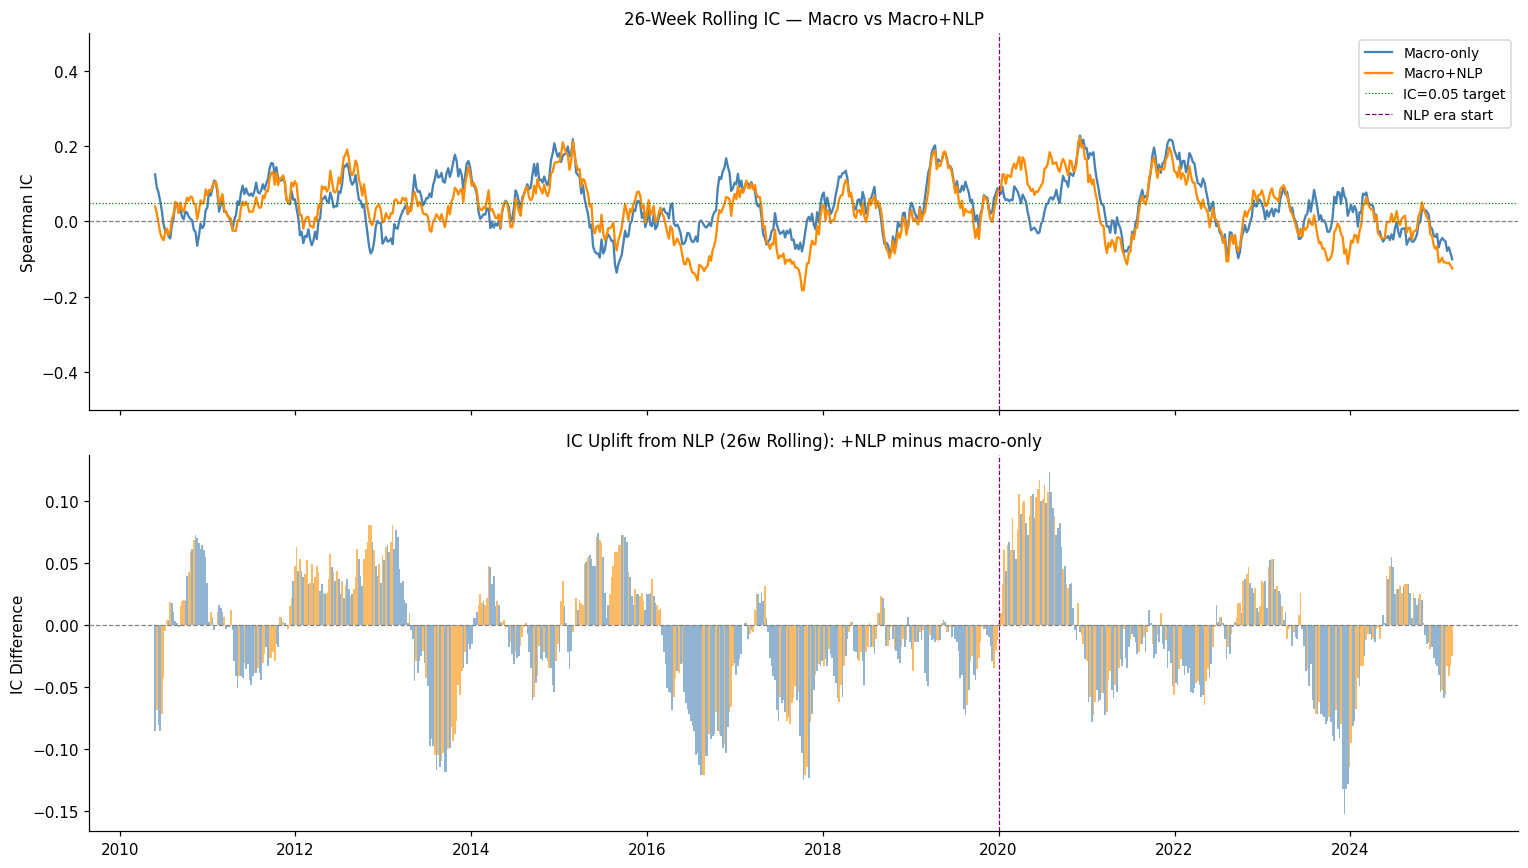

In [7]:
def ic_stats(res, label):
    ics = res['ic'].dropna()
    n   = len(ics)
    ic_mean = ics.mean()
    ic_std  = ics.std()
    tstat   = ic_mean / (ic_std / np.sqrt(n)) if ic_std > 0 else 0
    pval    = 2 * (1 - __import__('scipy').stats.norm.cdf(abs(tstat)))
    ic_pos  = (ics > 0).mean()
    return {'label': label, 'n': n, 'ic_mean': ic_mean, 'ic_std': ic_std,
            'tstat': tstat, 'pval': pval, 'ic_pos': ic_pos}


# Overall IC comparison
stats_all = [
    ic_stats(res_macro, 'Macro-only (NB13)'),
    ic_stats(res_nlp,   'Macro + NLP'),
]

# NLP-era IC comparison (2020+)
era_mask  = res_macro.index >= NLP_ERA_START
stats_era = [
    ic_stats(res_macro[era_mask], 'Macro-only [NLP era]'),
    ic_stats(res_nlp[era_mask],   'Macro+NLP  [NLP era]'),
]

print('IC Analysis — Full Period')
print('=' * 60)
print(f'{"Model":<28} {"IC mean":>8} {"IC std":>8} {"t-stat":>8} {"p":>8} {"IC+%":>7}')
print('-' * 60)
for s in stats_all:
    sig = '*' if s['pval'] < 0.05 else ''
    print(f"{s['label']:<28} {s['ic_mean']:>+8.4f} {s['ic_std']:>8.4f} "
          f"{s['tstat']:>8.3f} {s['pval']:>8.4f}{sig} {s['ic_pos']:>6.1%}")

print()
print(f'IC Analysis — NLP Era ({NLP_ERA_START.year}+)')
print('=' * 60)
print(f'{"Model":<28} {"IC mean":>8} {"IC std":>8} {"t-stat":>8} {"p":>8} {"IC+%":>7}')
print('-' * 60)
for s in stats_era:
    sig = '*' if s['pval'] < 0.05 else ''
    print(f"{s['label']:<28} {s['ic_mean']:>+8.4f} {s['ic_std']:>8.4f} "
          f"{s['tstat']:>8.3f} {s['pval']:>8.4f}{sig} {s['ic_pos']:>6.1%}")

# Rolling IC plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

roll26 = lambda s: s.rolling(26, min_periods=10).mean()

ax = axes[0]
ax.plot(roll26(res_macro['ic']), lw=1.5, label='Macro-only', color='steelblue')
ax.plot(roll26(res_nlp['ic']),   lw=1.5, label='Macro+NLP',  color='darkorange')
ax.axhline(0,  ls='--', color='gray', lw=0.8)
ax.axhline(0.05, ls=':', color='green', lw=0.8, label='IC=0.05 target')
ax.axvline(NLP_ERA_START, ls='--', color='purple', lw=0.8, label='NLP era start')
ax.set_title('26-Week Rolling IC — Macro vs Macro+NLP')
ax.set_ylabel('Spearman IC')
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 0.5)

ax2 = axes[1]
ic_diff = res_nlp['ic'] - res_macro['ic']
ax2.bar(ic_diff.index, roll26(ic_diff), color=ic_diff.apply(
    lambda x: 'darkorange' if x > 0 else 'steelblue'), alpha=0.6, width=7)
ax2.axhline(0, ls='--', color='gray', lw=0.8)
ax2.axvline(NLP_ERA_START, ls='--', color='purple', lw=0.8)
ax2.set_title('IC Uplift from NLP (26w Rolling): +NLP minus macro-only')
ax2.set_ylabel('IC Difference')

plt.tight_layout()
plt.savefig(FIGS / 'nlp_ic_comparison.png', dpi=110, bbox_inches='tight')
plt.show()


## Section 7 — Backtest Comparison

In [8]:
def perf_stats(ret_series, label):
    r = ret_series.dropna()
    ann_ret = r.mean() * 52
    ann_vol = r.std()  * np.sqrt(52)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
    cum     = (1 + r).cumprod()
    maxdd   = (cum / cum.cummax() - 1).min()
    winrate = (r > 0).mean()
    return {'label': label, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'max_dd': maxdd, 'winrate': winrate}


# Equal-weight benchmark
ew_ret = sector_df.loc[res_macro.index].mean(axis=1)

rows = [
    perf_stats(res_macro['gross_ret'],  'Macro-only (gross)'),
    perf_stats(res_macro['net_ret'],    'Macro-only (net TC)'),
    perf_stats(res_nlp['gross_ret'],    'Macro+NLP  (gross)'),
    perf_stats(res_nlp['net_ret'],      'Macro+NLP  (net TC)'),
    perf_stats(ew_ret,                  'Equal-Weight B&H'),
]

print(f'{"Strategy":<28} {"AnnRet":>8} {"AnnVol":>8} {"Sharpe":>8} {"MaxDD":>8} {"WinRate":>8}')
print('-' * 70)
for r in rows:
    print(f"{r['label']:<28} {r['ann_ret']:>7.2%} {r['ann_vol']:>8.2%} "
          f"{r['sharpe']:>8.2f} {r['max_dd']:>8.2%} {r['winrate']:>8.2%}")

# NLP era comparison
print(f'\nNLP Era ({NLP_ERA_START.year}+) Comparison:')
print('-' * 70)
era_rows = [
    perf_stats(res_macro.loc[era_mask, 'net_ret'], 'Macro-only (net TC) [era]'),
    perf_stats(res_nlp.loc[era_mask,   'net_ret'], 'Macro+NLP  (net TC) [era]'),
]
for r in era_rows:
    print(f"{r['label']:<28} {r['ann_ret']:>7.2%} {r['ann_vol']:>8.2%} "
          f"{r['sharpe']:>8.2f} {r['max_dd']:>8.2%} {r['winrate']:>8.2%}")


Strategy                       AnnRet   AnnVol   Sharpe    MaxDD  WinRate
----------------------------------------------------------------------
Macro-only (gross)             5.92%    8.53%     0.69  -13.77%   54.62%
Macro-only (net TC)          -14.88%    8.53%    -1.74  -90.34%   38.59%
Macro+NLP  (gross)             4.98%    8.51%     0.58  -14.06%   54.74%
Macro+NLP  (net TC)          -15.82%    8.51%    -1.86  -91.49%   37.69%
Equal-Weight B&H              13.54%   16.10%     0.84  -36.84%   58.21%

NLP Era (2020+) Comparison:
----------------------------------------------------------------------
Macro-only (net TC) [era]    -14.25%    8.78%    -1.62  -53.83%   37.04%
Macro+NLP  (net TC) [era]    -16.65%    8.40%    -1.98  -60.34%   35.93%


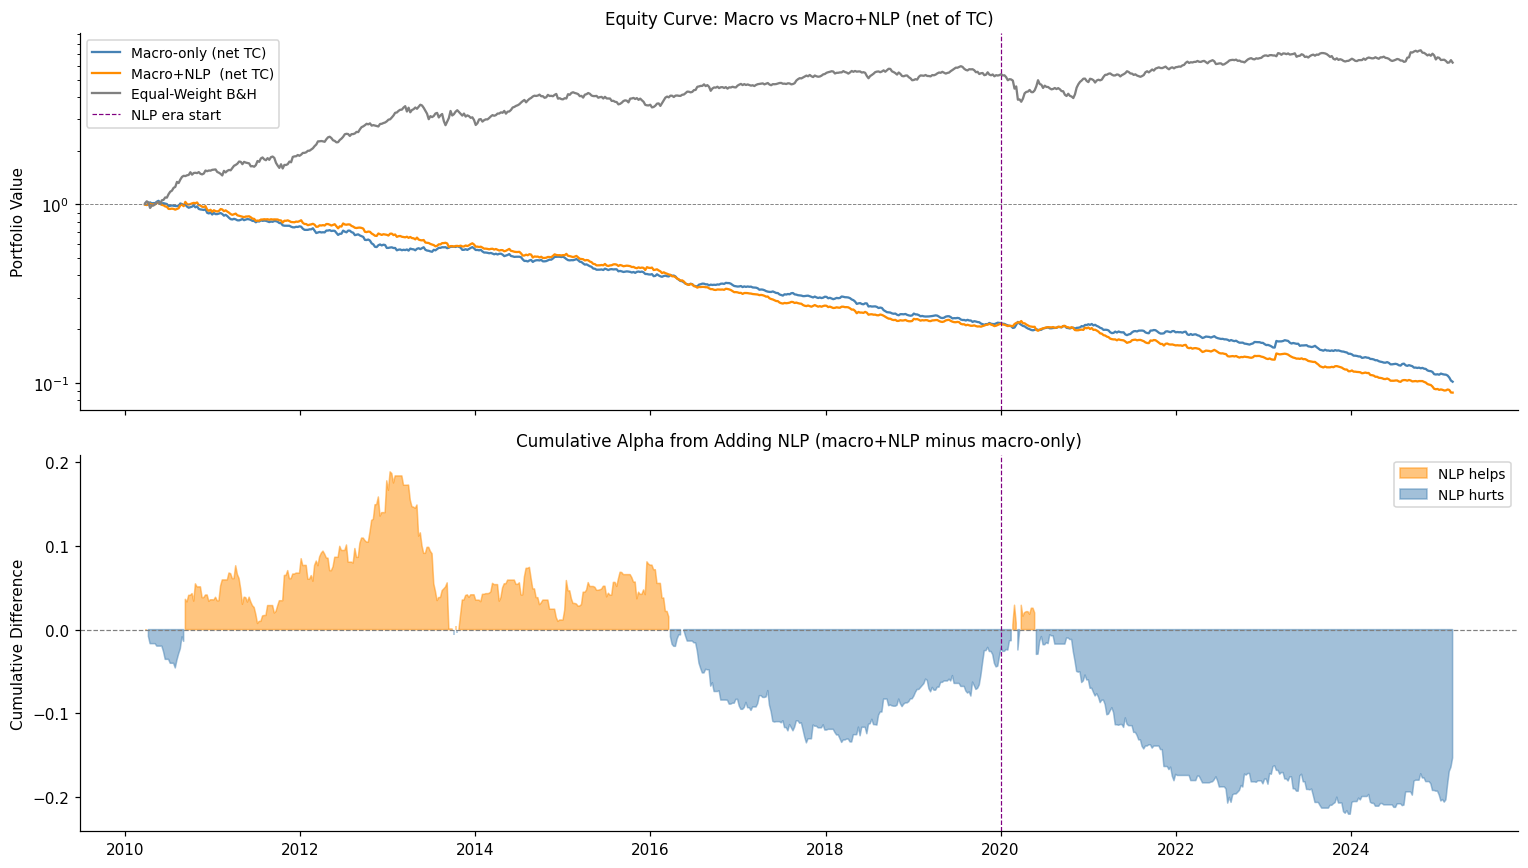

In [9]:
# Equity curve comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
for ret, label, color in [
    (res_macro['net_ret'], 'Macro-only (net TC)', 'steelblue'),
    (res_nlp['net_ret'],   'Macro+NLP  (net TC)', 'darkorange'),
    (ew_ret,               'Equal-Weight B&H',    'gray'),
]:
    cum = (1 + ret.dropna()).cumprod()
    ax.plot(cum, lw=1.5, label=label, color=color)

ax.axvline(NLP_ERA_START, ls='--', color='purple', lw=0.8, label='NLP era start')
ax.axhline(1, ls='--', color='gray', lw=0.6)
ax.set_title('Equity Curve: Macro vs Macro+NLP (net of TC)')
ax.set_ylabel('Portfolio Value')
ax.legend(fontsize=9)
ax.set_yscale('log')

ax2 = axes[1]
diff_net = res_nlp['net_ret'] - res_macro['net_ret']
diff_cum = (1 + diff_net.dropna()).cumprod() - 1
ax2.fill_between(diff_cum.index, 0, diff_cum,
                 where=diff_cum >= 0, alpha=0.5, color='darkorange', label='NLP helps')
ax2.fill_between(diff_cum.index, 0, diff_cum,
                 where=diff_cum < 0,  alpha=0.5, color='steelblue',  label='NLP hurts')
ax2.axhline(0, ls='--', color='gray', lw=0.8)
ax2.axvline(NLP_ERA_START, ls='--', color='purple', lw=0.8)
ax2.set_title('Cumulative Alpha from Adding NLP (macro+NLP minus macro-only)')
ax2.set_ylabel('Cumulative Difference')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / 'nlp_equity.png', dpi=110, bbox_inches='tight')
plt.show()


## Section 8 — NLP Feature Importance

Computing permutation importance on NLP era folds...



Top 20 features by IC drop:
  mom12_rank                     +0.0230  [MACRO]
  mom12                          +0.0100  [MACRO]
  mom1_rank                      +0.0056  [MACRO]
  mom4                           +0.0055  [MACRO]
  regime                         +0.0015  [MACRO]
  rvol12                         +0.0010  [MACRO]
  vix_z                          +0.0005  [MACRO]
  ICT_sent_4w                    +0.0004  [NLP]
  us_10yr_treasury_ret_w         +0.0003  [MACRO]
  yield_curve_slope              +0.0003  [MACRO]
  COMMERCE_sent_4w               +0.0003  [NLP]
  oil_ret_w                      +0.0001  [MACRO]
  COMMERCE_news_vol              +0.0001  [NLP]
  FOOD_news_vol                  +0.0001  [NLP]
  BANK_sent_lag1                 +0.0000  [NLP]
  ENERGY_sent_lag1               +0.0000  [NLP]
  HEALTH_sent_surp               +0.0000  [NLP]
  HEALTH_sent_lag1               +0.0000  [NLP]
  HEALTH_sent_4w                 +0.0000  [NLP]
  ICT_news_vol                   +0.000

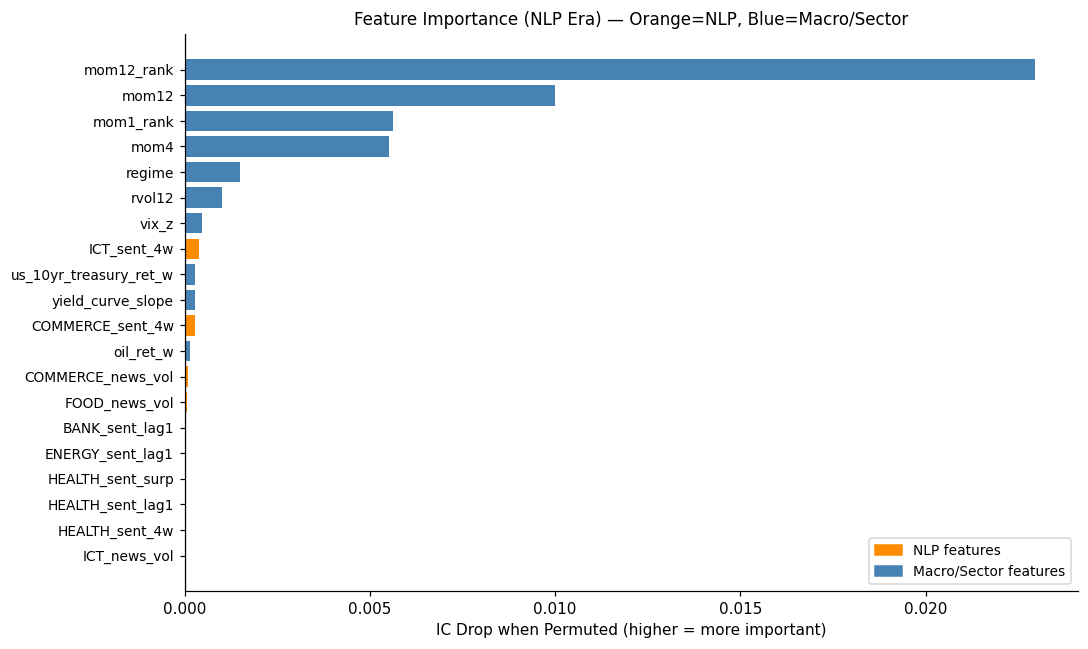

In [10]:
# Permutation IC importance: shuffle one NLP feature at a time
# Use the NLP-era test data only (where NLP has meaningful coverage)

from sklearn.base import clone

def permutation_ic_importance(panel, features, era_start, n_repeats=5,
                               min_train=156, fold_size=52):
    dates  = sorted(panel['date'].unique())
    n      = len(dates)
    feats  = [f for f in features if f in panel.columns]
    era_dt = pd.Timestamp(era_start)

    # Only score the last fold that falls in NLP era
    results = {}  # feat -> list of ic_drop

    t = min_train
    fold_results = []
    while t + fold_size <= n:
        train_d = dates[:t]
        test_d  = dates[t:t + fold_size]
        if pd.Timestamp(test_d[0]) < era_dt:
            t += fold_size
            continue

        train = panel[panel['date'].isin(train_d)]
        test  = panel[panel['date'].isin(test_d)]
        medians = train[feats].median()

        Xtr = train[feats].fillna(medians).fillna(0.).values.astype(float)
        Xte = test[feats].fillna(medians).fillna(0.).values.astype(float)
        ytr = train['fwd_excess'].values
        yte = test['fwd_excess'].values

        m = make_xgb(); m.fit(Xtr, ytr)
        base_pred = m.predict(Xte)
        base_ic   = spearmanr(base_pred, yte).statistic

        fold_imp = {}
        for fi, feat in enumerate(feats):
            drops = []
            for _ in range(n_repeats):
                Xte_perm = Xte.copy()
                Xte_perm[:, fi] = np.random.permutation(Xte_perm[:, fi])
                perm_ic = spearmanr(m.predict(Xte_perm), yte).statistic
                drops.append(base_ic - perm_ic)  # positive = feature helps
            fold_imp[feat] = np.mean(drops)

        fold_results.append(fold_imp)
        t += fold_size

    if not fold_results:
        return {}
    all_imps = pd.DataFrame(fold_results).mean()
    return all_imps.sort_values(ascending=False)


print('Computing permutation importance on NLP era folds...')
importance = permutation_ic_importance(panel, ALL_FEATS, NLP_ERA_START)

if isinstance(importance, pd.Series) and len(importance) > 0:
    top20 = importance.head(20)
    print(f'\nTop 20 features by IC drop:')
    for feat, val in top20.items():
        ftype = 'NLP' if any(s+'_' in feat for s in ['BANK','ENERGY','ICT',
                             'COMMERCE','HEALTH','PROPERTY','FOOD']) else 'MACRO'
        print(f'  {feat:<30} {val:>+.4f}  [{ftype}]')

    # Plot top-20
    colors = ['darkorange' if any(s+'_' in f for s in ['BANK','ENERGY','ICT',
               'COMMERCE','HEALTH','PROPERTY','FOOD']) else 'steelblue'
               for f in top20.index]
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(len(top20)), top20.values[::-1], color=colors[::-1])
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20.index[::-1], fontsize=9)
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_xlabel('IC Drop when Permuted (higher = more important)')
    ax.set_title('Feature Importance (NLP Era) — Orange=NLP, Blue=Macro/Sector')
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='darkorange', label='NLP features'),
        Patch(color='steelblue',  label='Macro/Sector features'),
    ], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGS / 'nlp_importance.png', dpi=110, bbox_inches='tight')
    plt.show()
else:
    print('No NLP-era folds found — skipping importance analysis.')


## Section 9 — Sector Sentiment Signal Analysis

In [11]:
# IC of raw sector sentiment vs forward excess return (by sector)
print('Sector-level sentiment IC vs forward excess return:')
print(f'{"Sector":<12} {"Feature":<22} {"IC":>8} {"p":>8} {"N":>6}')
print('-' * 60)

for sec in SECTORS:
    feat = f'{sec}_sent_lag1'
    if feat not in panel.columns:
        continue
    sub = panel[panel['sector'] == sec][[feat, 'fwd_excess']].dropna()
    if len(sub) < 20:
        print(f'  {sec:<12} {feat:<22} too few observations ({len(sub)})')
        continue
    ic, pval = spearmanr(sub[feat], sub['fwd_excess'])
    sig = '*' if pval < 0.05 else ''
    print(f'  {sec:<12} {feat:<22} {ic:>+8.4f} {pval:>8.4f}{sig} {len(sub):>6}')

print()
print('Cross-sectional relative sentiment IC vs forward excess:')
rel_feats = [f for f in panel.columns if f.endswith('_sent_rel')]
if rel_feats:
    sub = panel[rel_feats + ['fwd_excess']].dropna()
    # Flatten: stack sector relative sentiments
    sent_stack = []
    for sec in SECTORS:
        rf = f'{sec}_sent_rel'
        if rf not in panel.columns:
            continue
        tmp = panel[panel['sector'] == sec][[rf, 'fwd_excess']].dropna()
        tmp.columns = ['sent_rel', 'fwd_excess']
        sent_stack.append(tmp)
    if sent_stack:
        stacked = pd.concat(sent_stack)
        ic, pval = spearmanr(stacked['sent_rel'], stacked['fwd_excess'])
        print(f'  Cross-sectional sent_rel IC: {ic:+.4f}  (p={pval:.4f})')


Sector-level sentiment IC vs forward excess return:
Sector       Feature                      IC        p      N
------------------------------------------------------------
  BANK         BANK_sent_lag1          -0.0292   0.7776     96
  ENERGY       ENERGY_sent_lag1        -0.1064   0.2534    117
  ICT          ICT_sent_lag1           -0.0298   0.7362    130
  COMMERCE     COMMERCE_sent_lag1      -0.2065   0.0127*    145
  HEALTH       HEALTH_sent_lag1        +0.0355   0.7442     87
  PROPERTY     PROPERTY_sent_lag1      -0.0757   0.4635     96
  FOOD         FOOD_sent_lag1          +0.0239   0.8441     70

Cross-sectional relative sentiment IC vs forward excess:
  Cross-sectional sent_rel IC: -0.0885  (p=0.0160)


## Section 10 — Final Verdict

In [12]:
import scipy.stats as sps

# Full-period and NLP-era stats
mac_full  = ic_stats(res_macro,          'Macro-only full')
nlp_full  = ic_stats(res_nlp,            'NLP full')
mac_era   = ic_stats(res_macro[era_mask],'Macro-only NLP era')
nlp_era_s = ic_stats(res_nlp[era_mask],  'NLP NLP era')

nlp_perf_gross = perf_stats(res_nlp['gross_ret'], 'NLP gross')
nlp_perf_net   = perf_stats(res_nlp['net_ret'],   'NLP net')
nlp_era_net    = perf_stats(res_nlp.loc[era_mask,'net_ret'], 'NLP era net')
mac_era_net    = perf_stats(res_macro.loc[era_mask,'net_ret'],'Mac era net')

ic_uplift = nlp_full['ic_mean'] - mac_full['ic_mean']
ic_uplift_era = nlp_era_s['ic_mean'] - mac_era['ic_mean']

evidence = [
    ('IC mean > 0.05 (NLP)',            nlp_full['ic_mean'],     0.05,   '>', True),
    ('NLP IC > Macro IC (full)',         ic_uplift,               0,      '>', True),
    ('NLP IC significant (p<0.05)',      nlp_full['pval'],        0.05,   '<', False),
    ('NLP IC uplift in NLP era',         ic_uplift_era,           0,      '>', True),
    ('Sharpe net TC > 0 (full)',         nlp_perf_net['sharpe'],  0,      '>', True),
    ('Sharpe net TC > Macro (NLP era)',  nlp_era_net['sharpe'] - mac_era_net['sharpe'], 0, '>', True),
    ('Annual return net > 0%',           nlp_perf_net['ann_ret'], 0,      '>', True),
    ('NLP-era ann ret > Macro era',      nlp_era_net['ann_ret'] - mac_era_net['ann_ret'], 0, '>', True),
    ('Max DD (net) > -50%',              nlp_perf_net['max_dd'], -0.50,   '>', True),
]

score = 0
print('='*70)
print('SECTOR NLP ALPHA VERDICT')
print('='*70)
print(f'{"Evidence":<42} {"Value":>12}  {"Threshold":>10}')
print('-'*70)
for desc, val, thr, op, higher_better in evidence:
    passed = (val > thr) if op == '>' else (val < thr)
    mark   = '[+]' if passed else '[-]'
    score += passed
    if isinstance(val, float) and abs(val) < 1:
        print(f'{mark} {desc:<40} {val:>+12.4f}  {op}{thr:>9.4f}')
    else:
        print(f'{mark} {desc:<40} {val:>+12.2%}  {op}{thr:>9.2%}')

print(f'\nScore: {score}/{len(evidence)}')
print()
print('='*70)
if score >= 6:
    print('VERDICT: NLP ADDS MEANINGFUL SIGNAL')
    print('Sector NLP improves IC and/or Sharpe. Worth deploying in production.')
elif score >= 4:
    print('VERDICT: NLP ADDS MARGINAL SIGNAL')
    print('NLP shows some uplift but not consistent. Needs more news coverage.')
else:
    print('VERDICT: NLP DOES NOT ADD MEANINGFUL SIGNAL')
    print('Sector NLP insufficient. TC still dominates. Need denser news history.')
print('='*70)

print(f'\nKey metrics summary:')
print(f'  Macro IC mean (full):     {mac_full["ic_mean"]:+.4f}')
print(f'  NLP IC mean (full):       {nlp_full["ic_mean"]:+.4f}')
print(f'  IC Uplift:                {ic_uplift:+.4f}')
print(f'  Macro IC mean (NLP era):  {mac_era["ic_mean"]:+.4f}')
print(f'  NLP IC mean (NLP era):    {nlp_era_s["ic_mean"]:+.4f}')
print(f'  IC Uplift (NLP era):      {ic_uplift_era:+.4f}')
print(f'  NLP Sharpe net (full):    {nlp_perf_net["sharpe"]:+.2f}')
print(f'  NLP Sharpe net (era):     {nlp_era_net["sharpe"]:+.2f}')
print(f'  Macro Sharpe net (era):   {mac_era_net["sharpe"]:+.2f}')


SECTOR NLP ALPHA VERDICT
Evidence                                          Value   Threshold
----------------------------------------------------------------------
[-] IC mean > 0.05 (NLP)                          +0.0306  >   0.0500
[-] NLP IC > Macro IC (full)                      -0.0083  >   0.0000
[+] NLP IC significant (p<0.05)                   +0.0370  <   0.0500
[-] NLP IC uplift in NLP era                      -0.0054  >   0.0000
[-] Sharpe net TC > 0 (full)                     -185.85%  >    0.00%
[-] Sharpe net TC > Macro (NLP era)               -0.3598  >   0.0000
[-] Annual return net > 0%                        -0.1582  >   0.0000
[-] NLP-era ann ret > Macro era                   -0.0241  >   0.0000
[-] Max DD (net) > -50%                           -0.9149  >  -0.5000

Score: 1/9

VERDICT: NLP DOES NOT ADD MEANINGFUL SIGNAL
Sector NLP insufficient. TC still dominates. Need denser news history.

Key metrics summary:
  Macro IC mean (full):     +0.0389
  NLP IC mean (full)